In [ ]:
import sys
import os
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.signal import find_peaks

# Captum (Interpretability)
from captum.attr import IntegratedGradients, Occlusion, GradientShap
sys.path.append("..")

from config import *
from utils.balanced_builders_hdf import *
from data_cleaning.data_cleaning_wavelength import *

allowed_ids = set(np.load("balanced_ids_master.npy", allow_pickle=True))


c:\Users\doaam\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\doaam\AppData\Local\Programs\Python\Python311\Lib\site-packages\pybtex\plugin\__init__.py:26: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
#recover_all_cifs("BAnYPzBgOTlWjqY5lJnISdgC14cGyUNB")

In [ ]:
simulate_xrd_to_hdf5(
    allowed_ids=allowed_ids,
    base_dirs=["recovered_cifs"],   
    out_file="xrd_dataset.h5",
    theta_range=(10, 90),
    num_points=2048,
    n_patterns_per_cif=15,
    max_cifs=5
)

c:\Users\doaam\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\doaam\AppData\Local\Programs\Python\Python311\Lib\site-packages\pybtex\plugin\__init__.py:26: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources



🔹 Processing CIF: mp-1.cif  (1/5)
1.5406
   Diffraction computed (29 peaks)
   Augmenting 15 patterns...
1.5406
   Diffraction computed (29 peaks)
   Augmenting 15 patterns...
1.5444
   Diffraction computed (29 peaks)
   Augmenting 15 patterns...
1.5406
   Diffraction computed (29 peaks)
   Augmenting 15 patterns...
1.5444
   Diffraction computed (29 peaks)
   Augmenting 15 patterns...
1.5406
   Diffraction computed (29 peaks)
   Augmenting 15 patterns...
1.5444
   Diffraction computed (29 peaks)
   Augmenting 15 patterns...
1.5406
   Diffraction computed (29 peaks)
   Augmenting 15 patterns...
1.5406
   Diffraction computed (29 peaks)
   Augmenting 15 patterns...
1.5406
   Diffraction computed (29 peaks)
   Augmenting 15 patterns...
1.5444
   Diffraction computed (29 peaks)
   Augmenting 15 patterns...
1.5444
   Diffraction computed (29 peaks)
   Augmenting 15 patterns...
1.5444
   Diffraction computed (29 peaks)
   Augmenting 15 patterns...
1.5444
   Diffraction computed (29 peaks)


c:\Users\doaam\AppData\Local\Programs\Python\Python311\Lib\site-packages\pymatgen\core\structure.py:3102: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


   Diffraction computed (38 peaks)
   Augmenting 15 patterns...
1.5406
   Diffraction computed (38 peaks)
   Augmenting 15 patterns...
1.5444
   Diffraction computed (38 peaks)
   Augmenting 15 patterns...
1.5406
   Diffraction computed (38 peaks)
   Augmenting 15 patterns...
1.5406
   Diffraction computed (38 peaks)
   Augmenting 15 patterns...
1.5406
   Diffraction computed (38 peaks)
   Augmenting 15 patterns...
1.5406
   Diffraction computed (38 peaks)
   Augmenting 15 patterns...
1.5444
   Diffraction computed (38 peaks)
   Augmenting 15 patterns...
1.5444
   Diffraction computed (38 peaks)
   Augmenting 15 patterns...
1.5444
   Diffraction computed (38 peaks)
   Augmenting 15 patterns...
1.5406
   Diffraction computed (38 peaks)
   Augmenting 15 patterns...

🔹 Processing CIF: mp-10008.cif  (3/5)
1.5444
   Diffraction computed (32 peaks)
   Augmenting 15 patterns...
1.5406
   Diffraction computed (32 peaks)
   Augmenting 15 patterns...
1.5444
   Diffraction computed (32 peaks)
   

c:\Users\doaam\AppData\Local\Programs\Python\Python311\Lib\site-packages\pymatgen\core\structure.py:3102: UserWarning: Issues encountered while parsing CIF: 14 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


   Diffraction computed (337 peaks)
   Augmenting 15 patterns...
1.5406
   Diffraction computed (337 peaks)
   Augmenting 15 patterns...
1.5444
   Diffraction computed (337 peaks)
   Augmenting 15 patterns...
1.5406
   Diffraction computed (337 peaks)
   Augmenting 15 patterns...
1.5406
   Diffraction computed (337 peaks)
   Augmenting 15 patterns...
1.5406
   Diffraction computed (337 peaks)
   Augmenting 15 patterns...
1.5406
   Diffraction computed (337 peaks)
   Augmenting 15 patterns...
1.5444
   Diffraction computed (337 peaks)
   Augmenting 15 patterns...
1.5444
   Diffraction computed (337 peaks)
   Augmenting 15 patterns...
1.5406
   Diffraction computed (337 peaks)
   Augmenting 15 patterns...
1.5406
   Diffraction computed (337 peaks)
   Augmenting 15 patterns...
1.5444
   Diffraction computed (337 peaks)
   Augmenting 15 patterns...
1.5444
   Diffraction computed (337 peaks)
   Augmenting 15 patterns...
1.5444
   Diffraction computed (337 peaks)
   Augmenting 15 patterns...

In [2]:
len(allowed_ids)

68961

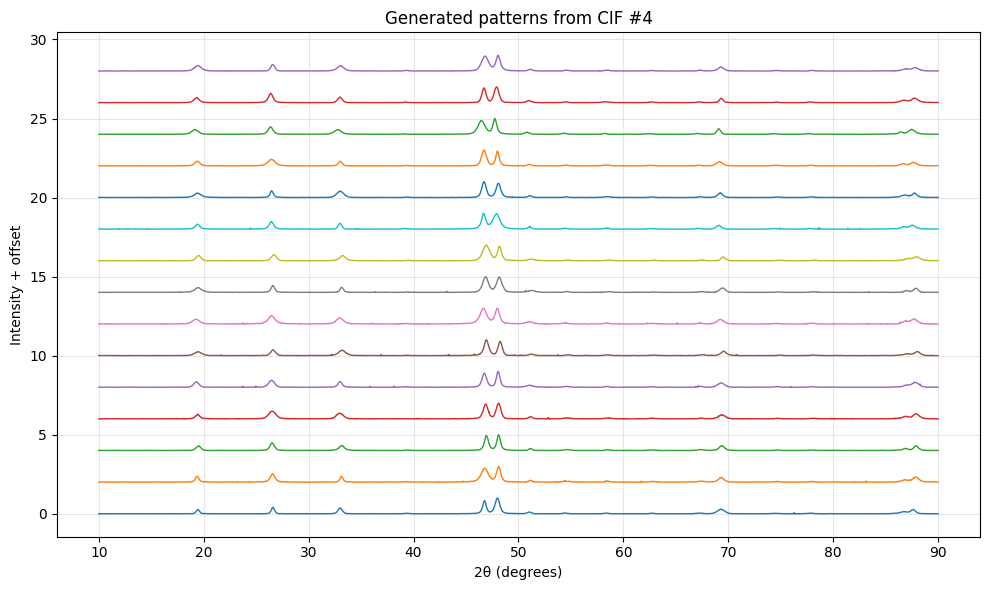

In [4]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

def plot_cif_group(h5_file, cif_index, n_patterns_per_cif, offset=0.8):
    with h5py.File(h5_file, "r") as f:
        xaxis = f["xaxis"][:]
        xrd = f["xrd"][:]

    start = cif_index * n_patterns_per_cif
    end = start + n_patterns_per_cif

    if end > len(xrd):
        print("CIF index out of range")
        return

    plt.figure(figsize=(10,6))

    for i in range(start, end):
        plt.plot(xaxis, xrd[i] + (i-start)*offset, lw=1)

    plt.xlabel("2θ (degrees)")
    plt.ylabel("Intensity + offset")
    plt.title(f"Generated patterns from CIF #{cif_index}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
plot_cif_group("xrd_dataset.h5", cif_index=4, n_patterns_per_cif=15, offset=2.0)

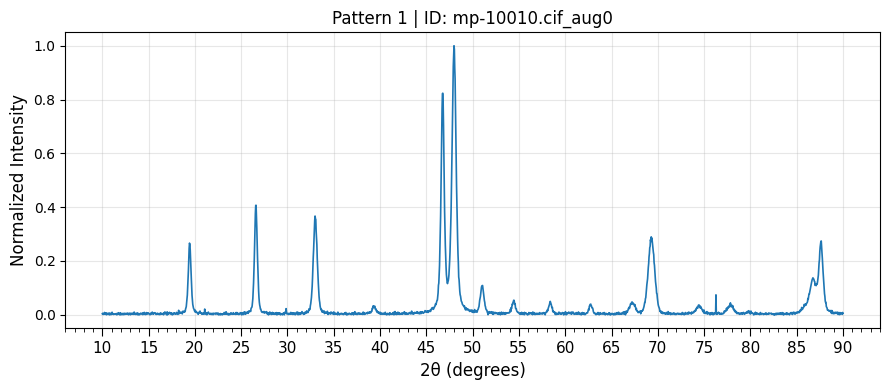

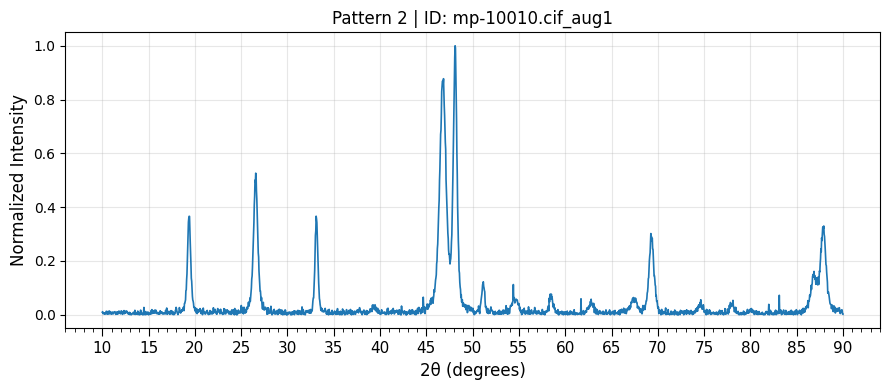

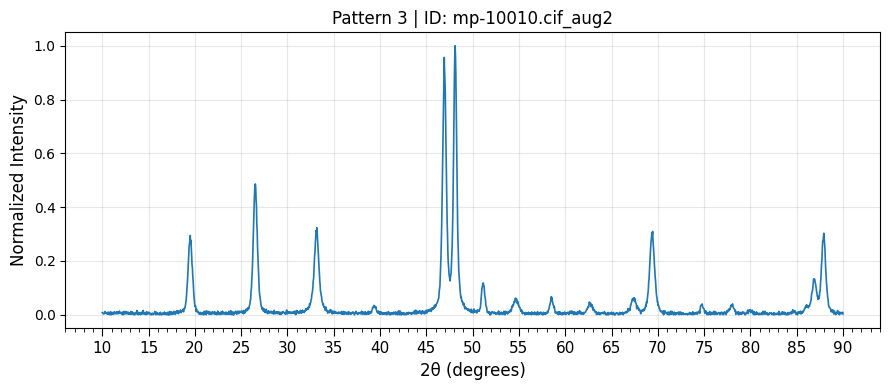

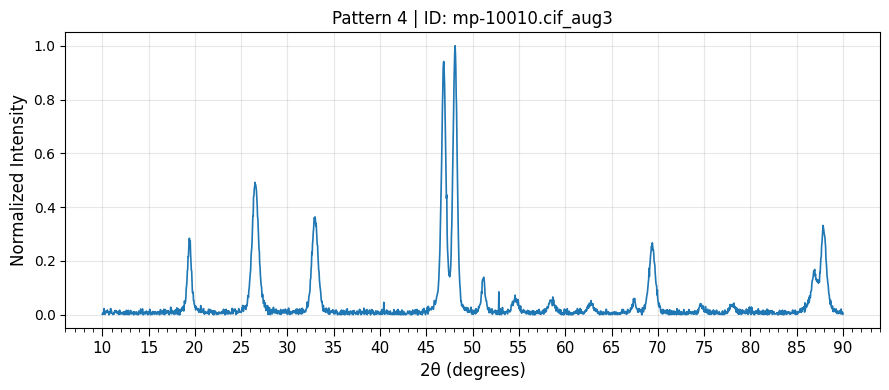

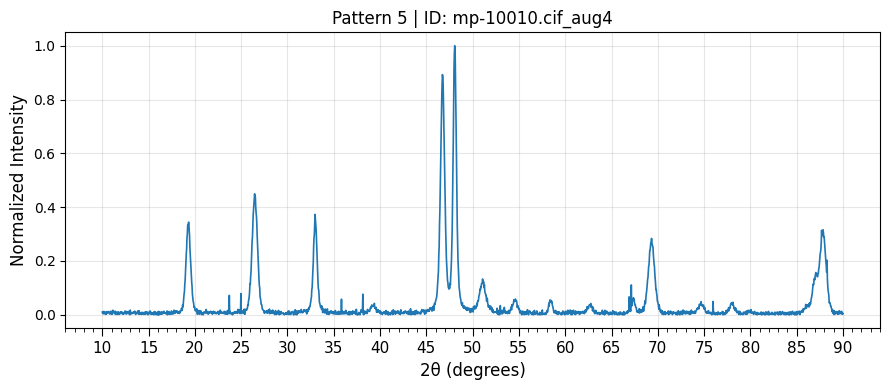

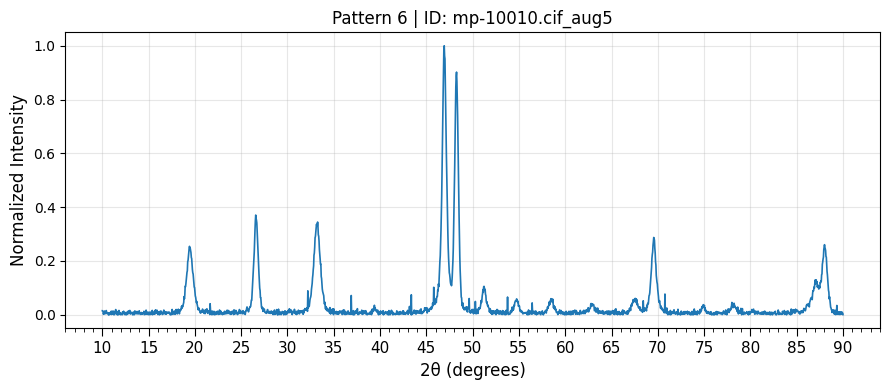

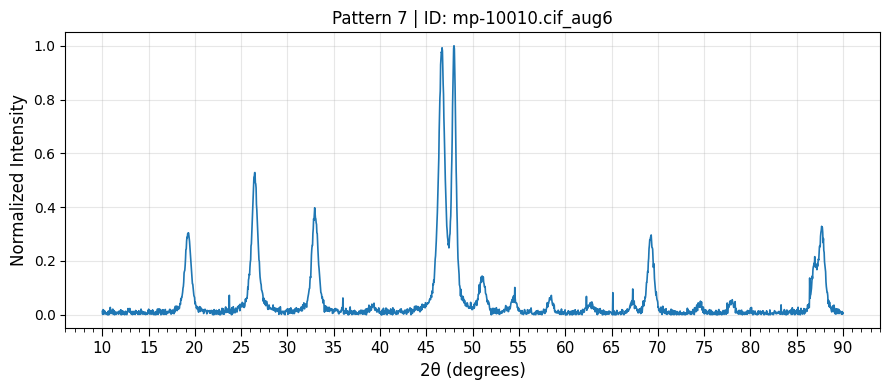

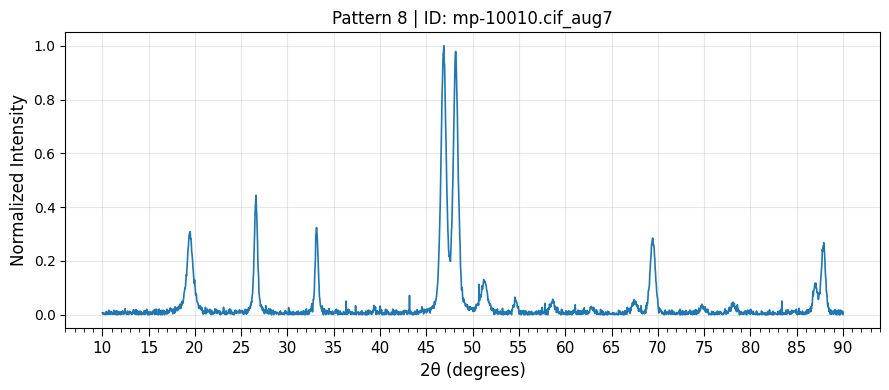

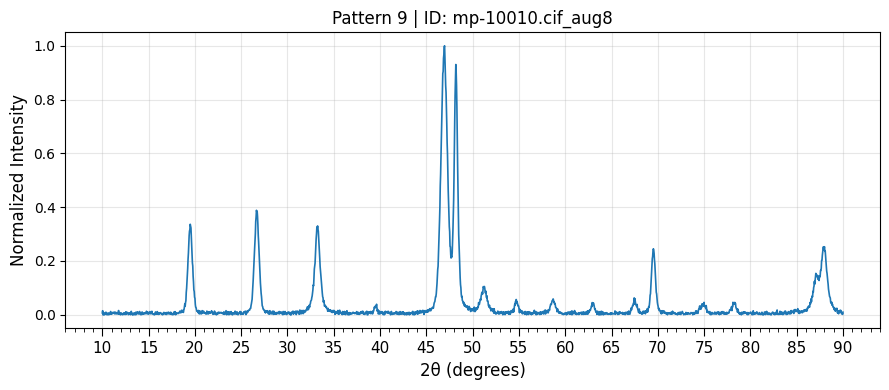

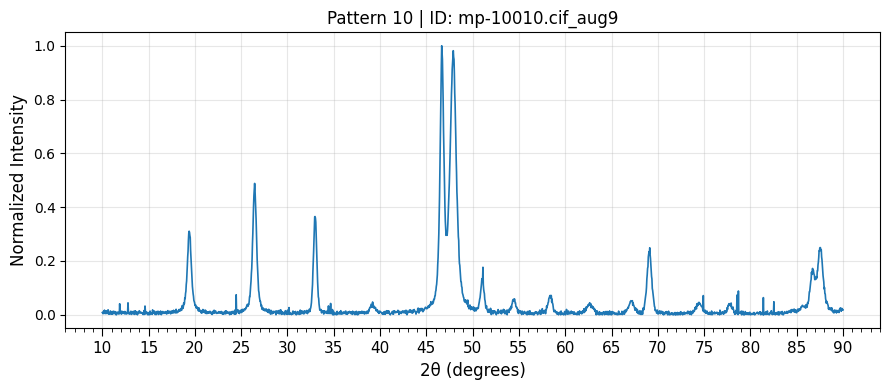

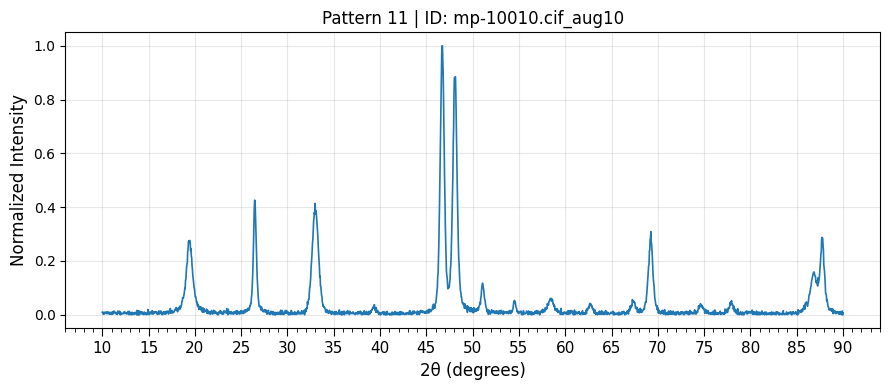

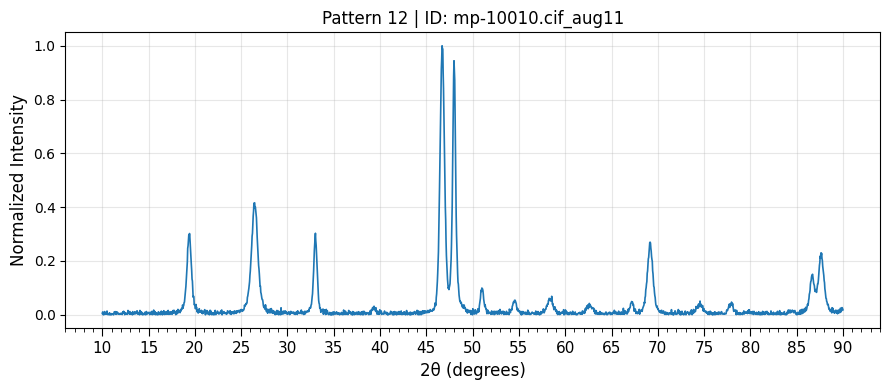

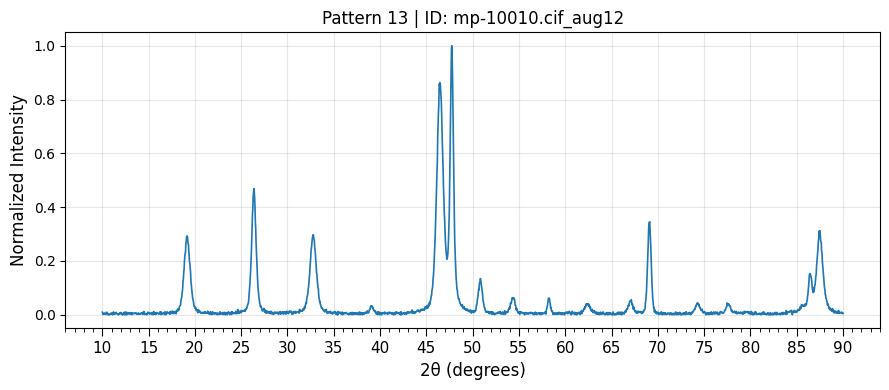

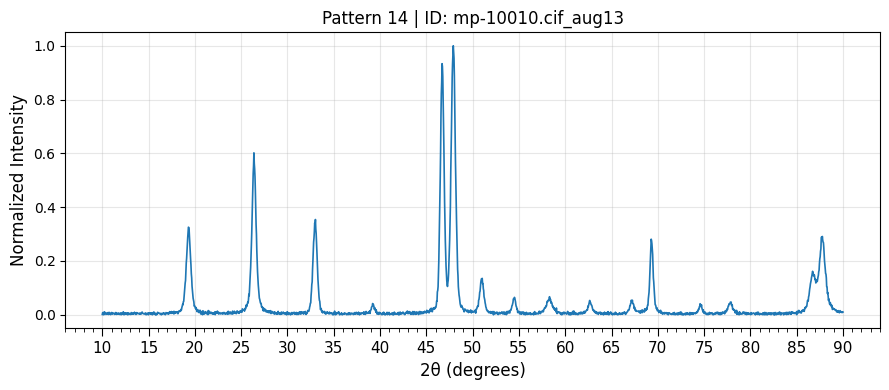

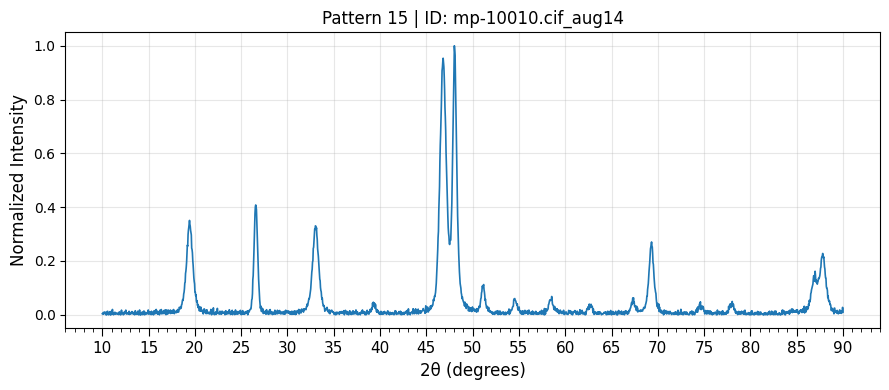

In [5]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

def plot_cif_group_separate(h5_file, cif_index, n_patterns_per_cif):
    with h5py.File(h5_file, "r") as f:
        xaxis = f["xaxis"][:]
        xrd = f["xrd"][:]
        ids = f["ids"][:]

    start = cif_index * n_patterns_per_cif
    end = start + n_patterns_per_cif

    if end > len(xrd):
        print("CIF index out of range")
        return

    for i in range(start, end):
        fig, ax = plt.subplots(figsize=(9, 4))

        ax.plot(xaxis, xrd[i], lw=1.2)

        # Labels
        ax.set_xlabel("2θ (degrees)", fontsize=12)
        ax.set_ylabel("Normalized Intensity", fontsize=12)

        # Title
        ax.set_title(
            f"Pattern {i-start+1} | ID: {ids[i].decode() if isinstance(ids[i], bytes) else ids[i]}",
            fontsize=12
        )

        # 🔹 Improve X-axis readability
        ax.xaxis.set_major_locator(MultipleLocator(5))     # major tick every 5°
        ax.xaxis.set_minor_locator(AutoMinorLocator(5))    # minor ticks between majors
        ax.tick_params(axis='x', which='major', labelsize=11, length=6)
        ax.tick_params(axis='x', which='minor', length=3)

        # Optional: rotate labels if crowded
        # plt.setp(ax.get_xticklabels(), rotation=30)

        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

plot_cif_group_separate("xrd_dataset.h5", cif_index=4, n_patterns_per_cif=15)

